In [ ]:
!sudo apt-get install p7zip-full -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [1]:
!7z x "/content/drive/MyDrive/Dangote Hackathon/IEEE 2012 PHM Prognostic Challenge dataset.7z" -o"/content/IEEE"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs AMD EPYC 7B12 (830F10),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/Dangote Hackathon/                                                   1 file, 195550299 bytes (187 MiB)

Extracting archive: /content/drive/MyDrive/Dangote Hackathon/IEEE 2012 PHM Prognostic Challenge dataset.7z
--
Path = /content/drive/MyDrive/Dangote Hackathon/IEEE 2012 PHM Prognostic Challenge dataset.7z
Type = 7z
Physical Size = 195550299
Headers Size = 197
Method = LZMA2:24
Solid = +
Blocks = 1

  0%      1% - testing_dataset.txt                            2% - testing_dataset.txt                            3% - testing_dataset.

Loading dataset pickle file...
Computing smoothed AHI for all bearing runs...

🎉 OPTIMAL UNIFORM ALERT THRESHOLD FOUND: 0.68
CONSECUTIVE HOLD-OFF WINDOW: 5 samples (0.5 seconds)
Bearing Asset   | Trigger (% Life)   | Lead Time to 0.2     | Early False Alarms
--------------------------------------------------------------------------------
Bearing 1_1     | 97.8%              | 3.1 seconds          | 0.0 seconds
Bearing 1_2     | 53.6%              | 40.3 seconds         | 0.0 seconds
Bearing 2_1     | 98.4%              | 1.4 seconds          | 0.0 seconds

💾 Final plot saved to '/content/ahi_trajectories_revamped.png'


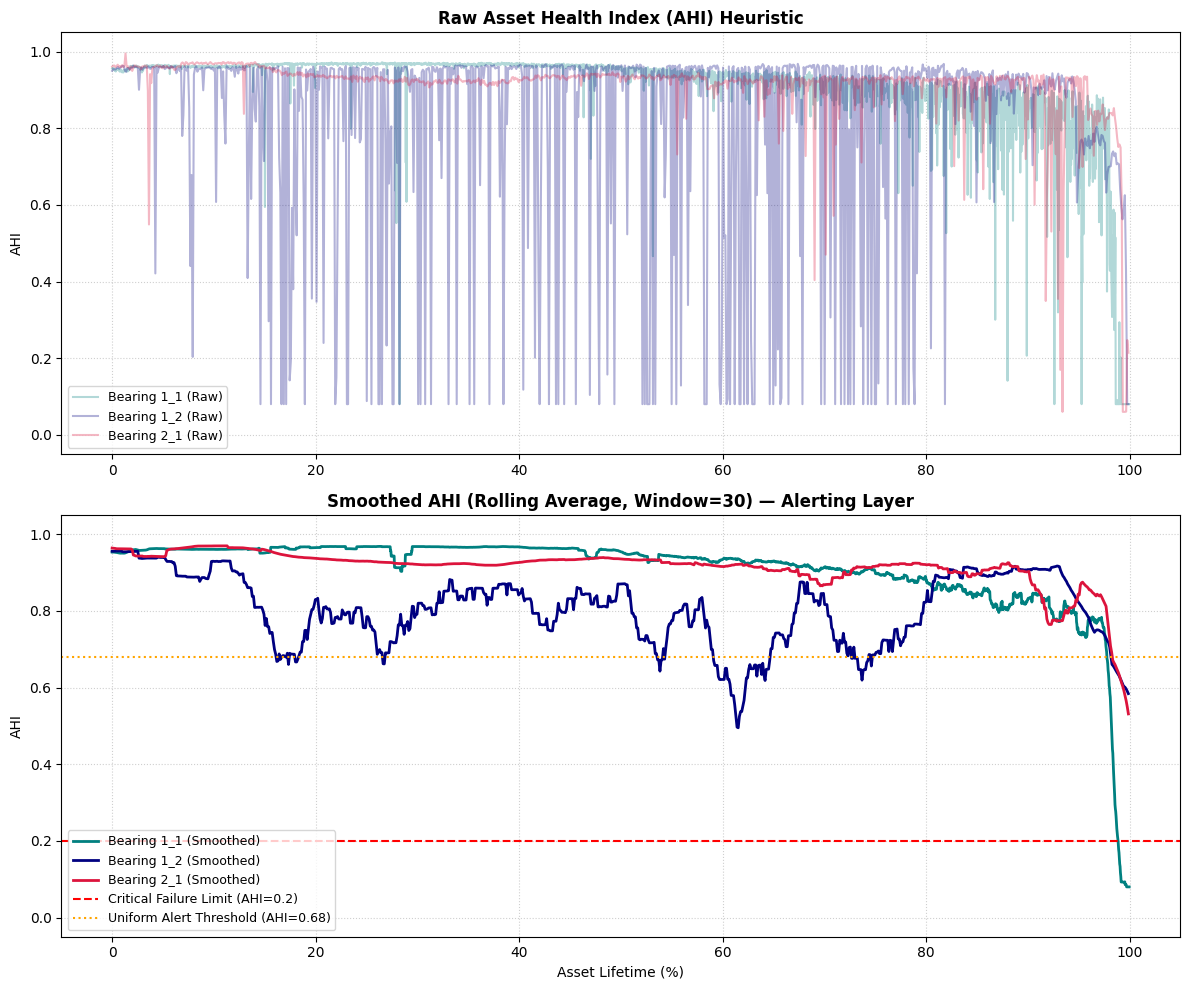

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. GLOBAL SYSTEM CONFIGURATION
# ==========================================
SMOOTHING_WINDOW = 30          # 3.0s rolling average
SAMPLING_INTERVAL = 0.1        # 10 Hz
CRITICAL_FAILURE_LIMIT = 0.2   # End-of-life threshold
MIN_CONSECUTIVE_SAMPLES = 5    # 0.5s confirmation (prevents transient false alarms)

# ==========================================
# 2. CORE MATHEMATICAL AHI HEURISTIC
# ==========================================
def calculate_heuristic_ahi(bearing_snapshots, load_p=0.8, smoothing_window=SMOOTHING_WINDOW):
    records = []
    total_snapshots = len(bearing_snapshots)
    for i, snapshot in enumerate(bearing_snapshots):
        try:
            horiz = snapshot[:, 4]
            vert = snapshot[:, 5]
            rms_h = np.sqrt(np.mean(horiz**2))
            rms_v = np.sqrt(np.mean(vert**2))
            rms_combined = np.sqrt((rms_h**2 + rms_v**2) / 2.0)
            mean_h = np.mean(horiz)
            std_h = np.std(horiz) if np.std(horiz) > 0 else 1e-6
            kurt = np.mean((horiz - mean_h)**4) / (std_h**4)
            a_score = min(1.0, rms_combined * (kurt / 3.0) / 10.0)
            e_dev_proxy = min(1.0, a_score * load_p)
            raw_wear = 0.6 * a_score + 0.4 * e_dev_proxy
            ahi = max(0.0, 1.0 - raw_wear)
            records.append({
                'lifetime_percent': (i / total_snapshots) * 100.0,
                'ahi_raw': ahi,
                'rms': rms_combined,
                'kurtosis': kurt
            })
        except Exception:
            continue
    df = pd.DataFrame(records)
    df['ahi'] = df['ahi_raw'].rolling(window=smoothing_window, min_periods=1, center=True).mean()
    return df

# ==========================================
# 3. ALERTING EVALUATION
# ==========================================
def compute_alert_metrics(ahi_series, alert_threshold, min_consecutive=MIN_CONSECUTIVE_SAMPLES):
    total_samples = len(ahi_series)
    consecutive_count = 0
    alert_idx = None
    failure_idx = None
    # Find critical failure (AHI <= 0.2)
    for idx, val in enumerate(ahi_series):
        if val <= CRITICAL_FAILURE_LIMIT:
            failure_idx = idx
            break
    if failure_idx is None:
        failure_idx = total_samples - 1
    # Find first alert that persists for min_consecutive samples, occurring before failure
    for idx in range(failure_idx):
        val = ahi_series.iloc[idx]
        if val < alert_threshold:
            consecutive_count += 1
            if consecutive_count >= min_consecutive:
                alert_idx = idx - min_consecutive + 1
                break
        else:
            consecutive_count = 0
    if alert_idx is not None:
        pct_lifetime_at_alert = (alert_idx / total_samples) * 100.0
        lead_time_sec = (failure_idx - alert_idx) * SAMPLING_INTERVAL
        false_alarm_time_sec = alert_idx * SAMPLING_INTERVAL if pct_lifetime_at_alert < 50.0 else 0.0
    else:
        pct_lifetime_at_alert = None
        lead_time_sec = 0.0
        false_alarm_time_sec = 0.0
    return {
        'pct_lifetime_at_alert': pct_lifetime_at_alert,
        'lead_time_sec': lead_time_sec,
        'false_alarm_time_sec': false_alarm_time_sec
    }

# ==========================================
# 4. THRESHOLD OPTIMIZER & TABLE GENERATOR
# ==========================================
def run_optimization_and_generate_table(dataset):
    print("Computing smoothed AHI for all bearing runs...")
    bearings = {
        'Bearing 1_1': calculate_heuristic_ahi(dataset[0], load_p=0.80),
        'Bearing 1_2': calculate_heuristic_ahi(dataset[1], load_p=0.80),
        'Bearing 2_1': calculate_heuristic_ahi(dataset[2], load_p=0.85)
    }
    best_threshold = None
    max_avg_lead_time = -1.0
    thresholds_to_test = np.linspace(0.30, 0.75, 46)
    for t in thresholds_to_test:
        t = round(t, 2)
        all_passed = True
        temp_lead_times = []
        for name, df in bearings.items():
            metrics = compute_alert_metrics(df['ahi'], t)
            if metrics['false_alarm_time_sec'] > 0:
                all_passed = False
                break
            if metrics['pct_lifetime_at_alert'] is not None and metrics['lead_time_sec'] > 0:
                temp_lead_times.append(metrics['lead_time_sec'])
            else:
                all_passed = False
                break
        if all_passed:
            avg_lead = np.mean(temp_lead_times)
            if avg_lead > max_avg_lead_time:
                max_avg_lead_time = avg_lead
                best_threshold = t
    if best_threshold is None:
        print("\n⚠️ Strict sweep failed; using safe default 0.50.")
        best_threshold = 0.50
    print("\n" + "="*80)
    print(f"🎉 OPTIMAL UNIFORM ALERT THRESHOLD FOUND: {best_threshold:.2f}")
    print(f"CONSECUTIVE HOLD-OFF WINDOW: {MIN_CONSECUTIVE_SAMPLES} samples ({MIN_CONSECUTIVE_SAMPLES*SAMPLING_INTERVAL:.1f} seconds)")
    print("="*80)
    print(f"{'Bearing Asset':<15} | {'Trigger (% Life)':<18} | {'Lead Time to 0.2':<20} | {'Early False Alarms'}")
    print("-" * 80)
    for name, df in bearings.items():
        metrics = compute_alert_metrics(df['ahi'], best_threshold)
        pct_str = f"{metrics['pct_lifetime_at_alert']:.1f}%" if metrics['pct_lifetime_at_alert'] is not None else "N/A"
        lead_str = f"{metrics['lead_time_sec']:.1f} seconds"
        fa_str = f"{metrics['false_alarm_time_sec']:.1f} seconds"
        print(f"{name:<15} | {pct_str:<18} | {lead_str:<20} | {fa_str}")
    print("="*80)
    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
    colors = {'Bearing 1_1': 'teal', 'Bearing 1_2': 'navy', 'Bearing 2_1': 'crimson'}
    for name, df in bearings.items():
        axes[0].plot(df['lifetime_percent'], df['ahi_raw'], label=f"{name} (Raw)", color=colors[name], alpha=0.3)
        axes[1].plot(df['lifetime_percent'], df['ahi'], label=f"{name} (Smoothed)", color=colors[name], linewidth=2.0)
    axes[0].set_title("Raw Asset Health Index (AHI) Heuristic", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("AHI", fontsize=10)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend(loc="lower left", fontsize=9)
    axes[0].set_ylim(-0.05, 1.05)
    axes[1].set_title(f"Smoothed AHI (Rolling Average, Window={SMOOTHING_WINDOW}) — Alerting Layer", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Asset Lifetime (%)", fontsize=10)
    axes[1].set_ylabel("AHI", fontsize=10)
    axes[1].axhline(CRITICAL_FAILURE_LIMIT, color='red', linestyle='--', linewidth=1.5, label='Critical Failure Limit (AHI=0.2)')
    axes[1].axhline(best_threshold, color='orange', linestyle=':', linewidth=1.5, label=f'Uniform Alert Threshold (AHI={best_threshold})')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend(loc="lower left", fontsize=9)
    axes[1].set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig("/content/ahi_trajectories_revamped.png", dpi=300)
    print("\n💾 Final plot saved to '/content/ahi_trajectories_revamped.png'")
    plt.show()

# ==========================================
# 5. EXECUTION
# ==========================================
filepath = "/content/IEEE/training_dataset.txt"
print("Loading dataset pickle file...")
with open(filepath, "rb") as f:
    dataset = pickle.load(f)
run_optimization_and_generate_table(dataset)

Loading testing dataset pickle file from: /content/IEEE/testing_dataset.txt...
Loaded successfully. Total test bearings found: 11

🚀 EXECUTING UNSEEN RUN EVALUATION (THRESHOLD = 0.68)
Bearing Asset   | Duration (s) | Trigger (% Life)   | Trigger Time (s)   | Early False Alarm
-----------------------------------------------------------------------------------------------
Bearing 1_3     | 180.2s       | 98.5%              | 177.5s             | ✅ None
Bearing 1_4     | 113.9s       | 96.6%              | 110.0s             | ✅ None
Bearing 1_5     | 230.2s       | No Trigger         | N/A                | ✅ None
Bearing 1_6     | 230.2s       | 71.0%              | 163.4s             | ✅ None
Bearing 1_7     | 150.2s       | No Trigger         | N/A                | ✅ None
Bearing 2_3     | 120.2s       | 21.5%              | 25.9s              | ⚠️ YES
Bearing 2_4     | 61.2s        | No Trigger         | N/A                | ✅ None
Bearing 2_5     | 200.2s       | No Trigger         |

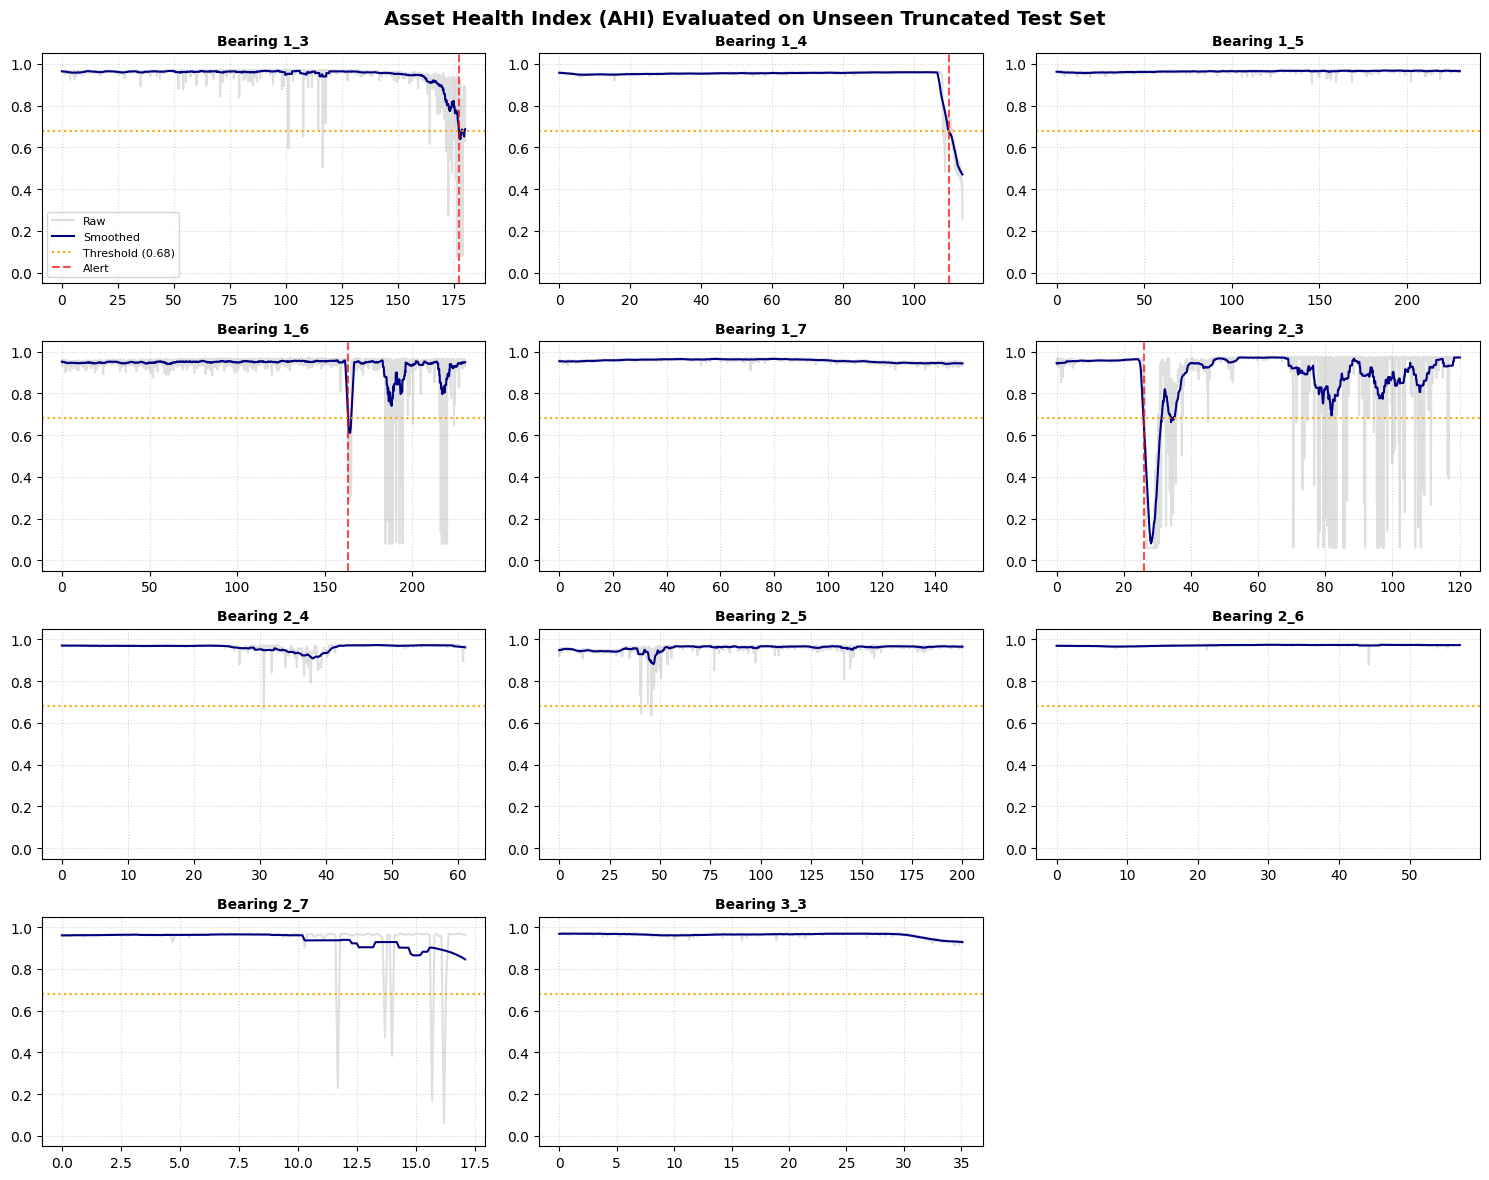

In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. GLOBAL SYSTEM CONFIGURATION (Shared with Training)
# ==========================================
SMOOTHING_WINDOW = 30          # 3.0s rolling average (at 10 Hz)
SAMPLING_INTERVAL = 0.1        # 10 Hz snapshot interval
OPTIMIZED_ALERT_THRESHOLD = 0.68  # Best threshold derived from training
MIN_CONSECUTIVE_SAMPLES = 5    # 0.5s confirmation window (noise suppression)
CRITICAL_FAILURE_LIMIT = 0.2   # Failure index boundary

# ==========================================
# 2. CORE MATHEMATICAL AHI HEURISTIC (Shared with Training)
# ==========================================
def calculate_heuristic_ahi(bearing_snapshots, load_p=0.80, smoothing_window=SMOOTHING_WINDOW):
    records = []
    total_snapshots = len(bearing_snapshots)
    for i, snapshot in enumerate(bearing_snapshots):
        try:
            horiz = snapshot[:, 4]
            vert = snapshot[:, 5]

            # A. Combined dual-axis root-mean-square energy
            rms_h = np.sqrt(np.mean(horiz**2))
            rms_v = np.sqrt(np.mean(vert**2))
            rms_combined = np.sqrt((rms_h**2 + rms_v**2) / 2.0)

            # B. Statistical Kurtosis
            mean_h = np.mean(horiz)
            std_h = np.std(horiz) if np.std(horiz) > 0 else 1e-6
            kurt = np.mean((horiz - mean_h)**4) / (std_h**4)

            # C. Normalized Anomaly Score
            a_score = min(1.0, rms_combined * (kurt / 3.0) / 10.0)

            # D. Operational Load-scaled proxy
            e_dev_proxy = min(1.0, a_score * load_p)

            # E. Multi-parameter deterministic composition
            raw_wear = 0.6 * a_score + 0.4 * e_dev_proxy
            ahi = max(0.0, 1.0 - raw_wear)

            records.append({
                'time_sec': i * SAMPLING_INTERVAL,
                'ahi_raw': ahi,
                'rms': rms_combined,
                'kurtosis': kurt
            })
        except Exception:
            continue

    df = pd.DataFrame(records)
    # Apply centered sliding rolling window smoothing
    df['ahi'] = df['ahi_raw'].rolling(window=smoothing_window, min_periods=1, center=True).mean()
    return df

# ==========================================
# 3. TRUNCATED RUN ALERT EVALUATION
# ==========================================
def evaluate_test_bearing_alerts(ahi_series, test_name, alert_threshold=OPTIMIZED_ALERT_THRESHOLD, min_consecutive=MIN_CONSECUTIVE_SAMPLES):
    total_samples = len(ahi_series)
    total_duration_sec = total_samples * SAMPLING_INTERVAL
    half_life_idx = total_samples // 2

    consecutive_count = 0
    alert_idx = None

    # Scan for alert trigger point
    for idx in range(total_samples):
        val = ahi_series.iloc[idx]
        if val < alert_threshold:
            consecutive_count += 1
            if consecutive_count >= min_consecutive:
                alert_idx = idx - min_consecutive + 1
                break
        else:
            consecutive_count = 0

    # Compile performance diagnostics
    triggered = alert_idx is not None
    pct_life_at_alert = (alert_idx / total_samples) * 100.0 if triggered else None
    alert_time_sec = alert_idx * SAMPLING_INTERVAL if triggered else None

    # An early false alarm is defined as any trigger occurring during the first 50% of the recorded test track
    early_false_alarm = triggered and (alert_idx < half_life_idx)
    early_fa_duration = alert_time_sec if early_false_alarm else 0.0

    return {
        'total_samples': total_samples,
        'total_duration_sec': total_duration_sec,
        'triggered': triggered,
        'pct_life_at_alert': pct_life_at_alert,
        'alert_time_sec': alert_time_sec,
        'early_false_alarm': early_false_alarm,
        'early_fa_duration': early_fa_duration
    }

# ==========================================
# 4. TESTING EXECUTION ENGINE
# ==========================================
def execute_testing_pipeline(test_dataset_path):
    print(f"Loading testing dataset pickle file from: {test_dataset_path}...")
    with open(test_dataset_path, "rb") as f:
        test_dataset = pickle.load(f)

    print(f"Loaded successfully. Total test bearings found: {len(test_dataset)}")

    # Identify test bearings using the standard PRONOSTIA test set sequence
    bearing_metadata = [
        {'name': 'Bearing 1_3', 'load_p': 0.80}, # Condition 1 (4.0 kN)
        {'name': 'Bearing 1_4', 'load_p': 0.80},
        {'name': 'Bearing 1_5', 'load_p': 0.80},
        {'name': 'Bearing 1_6', 'load_p': 0.80},
        {'name': 'Bearing 1_7', 'load_p': 0.80},
        {'name': 'Bearing 2_3', 'load_p': 0.85}, # Condition 2 (4.2 kN)
        {'name': 'Bearing 2_4', 'load_p': 0.85},
        {'name': 'Bearing 2_5', 'load_p': 0.85},
        {'name': 'Bearing 2_6', 'load_p': 0.85},
        {'name': 'Bearing 2_7', 'load_p': 0.85},
        {'name': 'Bearing 3_3', 'load_p': 0.90}  # Condition 3 (5.0 kN)
    ]

    results = []

    print("\n" + "="*95)
    print("🚀 EXECUTING UNSEEN RUN EVALUATION (THRESHOLD = 0.68)")
    print("="*95)
    print(f"{'Bearing Asset':<15} | {'Duration (s)':<12} | {'Trigger (% Life)':<18} | {'Trigger Time (s)':<18} | {'Early False Alarm'}")
    print("-" * 95)

    fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=False)
    axes_flat = axes.flatten()

    for i, meta in enumerate(bearing_metadata):
        if i >= len(test_dataset):
            break

        name = meta['name']
        load_val = meta['load_p']

        # Calculate AHI
        df_ahi = calculate_heuristic_ahi(test_dataset[i], load_p=load_val)

        # Evaluate alert triggers
        metrics = evaluate_test_bearing_alerts(df_ahi['ahi'], name)
        results.append((name, metrics))

        # Format terminal log output
        dur_str = f"{metrics['total_duration_sec']:.1f}s"
        pct_str = f"{metrics['pct_life_at_alert']:.1f}%" if metrics['triggered'] else "No Trigger"
        trig_time_str = f"{metrics['alert_time_sec']:.1f}s" if metrics['triggered'] else "N/A"
        fa_str = "⚠️ YES" if metrics['early_false_alarm'] else "✅ None"

        print(f"{name:<15} | {dur_str:<12} | {pct_str:<18} | {trig_time_str:<18} | {fa_str}")

        # Plot individual subplot
        ax = axes_flat[i]
        ax.plot(df_ahi['time_sec'], df_ahi['ahi_raw'], color='gray', alpha=0.25, label='Raw')
        ax.plot(df_ahi['time_sec'], df_ahi['ahi'], color='navy', linewidth=1.5, label='Smoothed')
        ax.axhline(OPTIMIZED_ALERT_THRESHOLD, color='orange', linestyle=':', label='Threshold (0.68)')

        if metrics['triggered']:
            ax.axvline(metrics['alert_time_sec'], color='red', linestyle='--', alpha=0.7, label='Alert')

        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle=':', alpha=0.5)
        if i == 0:
            ax.legend(loc='lower left', fontsize=8)

    # Hide unused subplots
    for j in range(len(bearing_metadata), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.suptitle("Asset Health Index (AHI) Evaluated on Unseen Truncated Test Set", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("/content/ahi_unseen_test_trajectories.png", dpi=300)
    print("="*95)
    print("\n💾 Diagnostic test trajectories plotted and saved to '/content/ahi_unseen_test_trajectories.png'")

# ==========================================
# 5. EXECUTION BOOTSTRAP
# ==========================================
if __name__ == "__main__":
    # Point this to your target test file location
    test_filepath = "/content/IEEE/testing_dataset.txt"
    try:
        execute_testing_pipeline(test_filepath)
    except FileNotFoundError:
        print(f"Error: Could not locate test dataset at {test_filepath}. Please verify path.")